# Medical Insurance Cost Prediction — Linear Regression
### Mini Project : EDA → Preprocessing → Model Training → Evaluation & Diagnostics

This notebook predicts individual medical insurance charges from `age`, `sex`, `bmi`, `children`, `smoker`, and `region`, comparing Linear Regression, Ridge, and Lasso, and diagnosing the final model's assumptions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
%matplotlib inline

## Module 1 — Dataset Selection & EDA

In [2]:
df = pd.read_csv("../data/insurance.csv")
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1
Shape after dropping duplicates: (1337, 7)


In [5]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.describe(include='object')

C:\Users\shreyas\AppData\Local\Temp\ipykernel_22536\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [7]:
print("Skewness ")
print("Age : ",round(df['age'].skew(),3))
print("Bmi : ",round(df['bmi'].skew(),3))
print("charges : ",round(df['charges'].skew(),3))

Skewness 
Age :  0.055
Bmi :  0.284
charges :  1.515


In [8]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5*iqr
    up = q3 + 1.5*iqr
    return series[(series<lb) | (series>up) ]

print("BMI outlayers ",len(iqr_outliers(df['bmi'])))
print("Charges outliers:", len(iqr_outliers(df["charges"])), f'({len(iqr_outliers(df["charges"]))/len(df)*100:.1f}% of data)')

BMI outlayers  9
Charges outliers: 139 (10.4% of data)


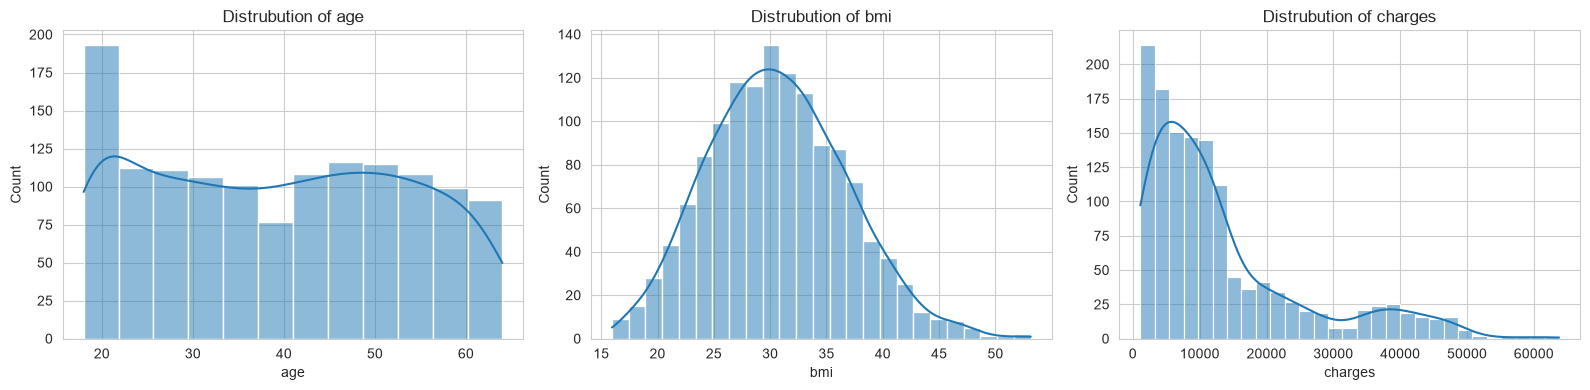

In [9]:
fig,axes = plt.subplots(1,3,figsize=(16,4))

for ax,col in zip(axes,["age", "bmi", "charges"]) :
    sns.histplot(df[col],kde=True,ax=ax)
    ax.set_title(f"Distrubution of {col}")
plt.tight_layout()
plt.savefig("../images/univarient_numeric.png",dpi=300)
plt.show()

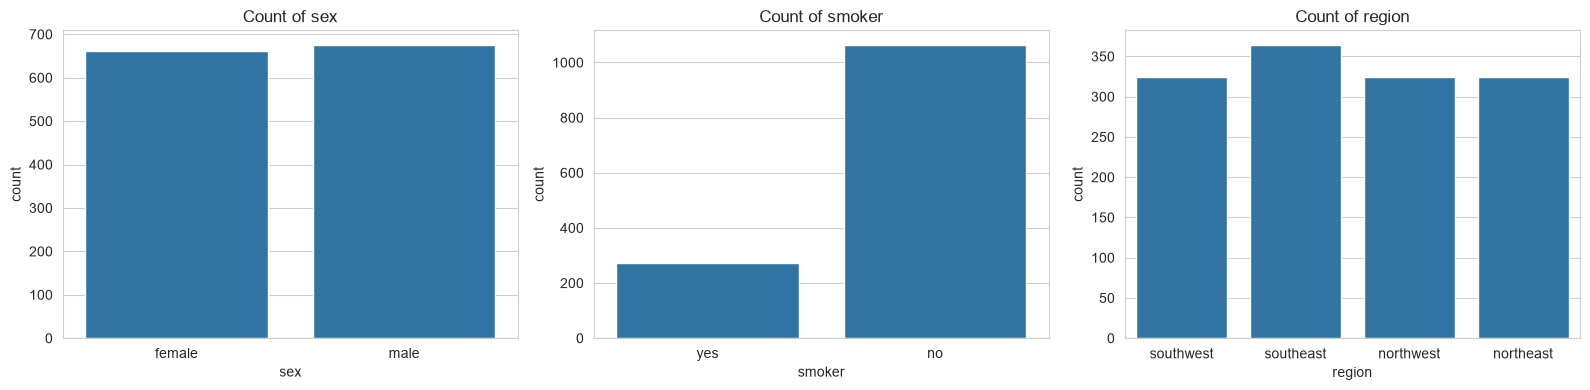

In [10]:
fig,axes = plt.subplots(1,3,figsize=(16,4))

for ax,col in zip(axes,["sex", "smoker", "region"]) :
    sns.countplot(data = df,x= col,ax=ax)
    ax.set_title(f"Count of {col}")
plt.tight_layout()
plt.savefig("../images/univarient_categoric.png",dpi=300)
plt.show()

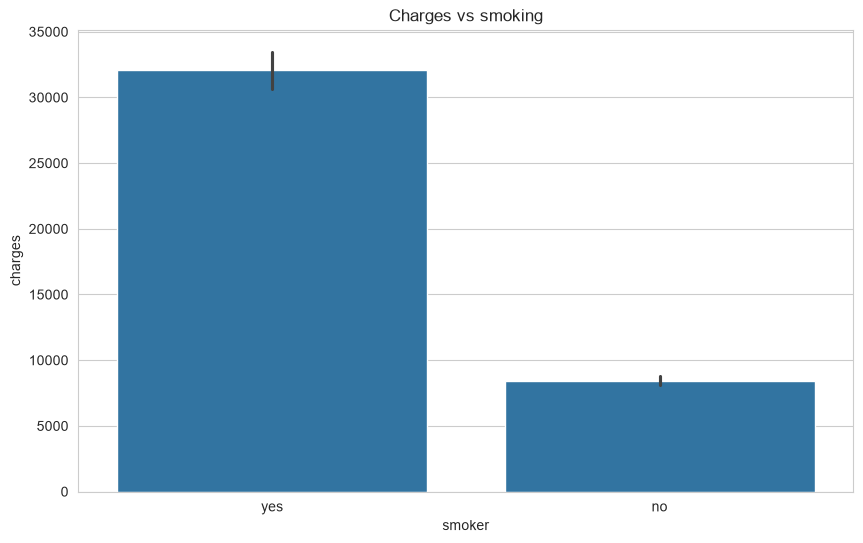

smoker
no      8440.66
yes    32050.23
Name: charges, dtype: float64


In [11]:
plt.figure(figsize=(10,6))
sns.barplot(x='smoker',y='charges',data=df)
plt.title("Charges vs smoking")
plt.savefig("../images/charges_by_Smoking.png", dpi=100)
plt.show()
print(df.groupby("smoker")["charges"].mean().round(2))

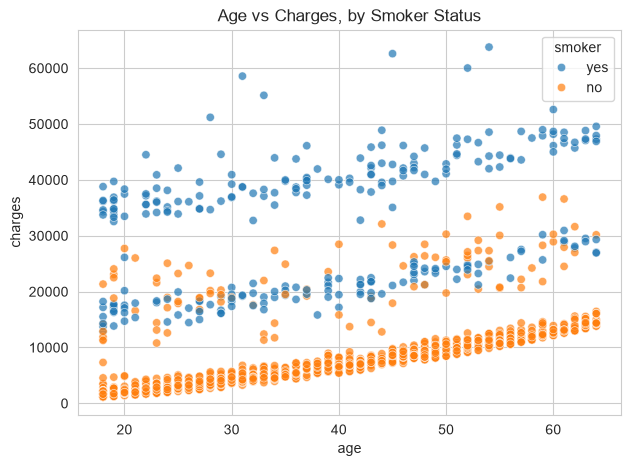

In [12]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="age",y="charges",hue="smoker",data=df,alpha=0.7)
plt.title("Age vs Charges, by Smoker Status")
plt.savefig("../images/age_vs_charges.png", dpi=100)
plt.show()

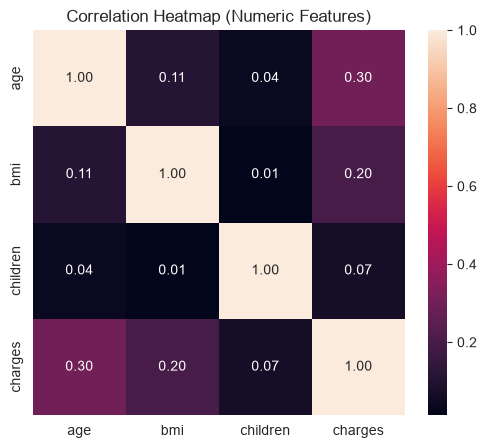

In [13]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["age", "bmi", "children", "charges"]].corr(),annot=True,fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.savefig("../images/correlation_heatmap.png", dpi=100)
plt.show()

**Module 1 Key Insights**
- No missing values; 1 duplicate row found and dropped (1338 → 1337 rows)
- `charges` is heavily right-skewed (skew ≈ 1.51) — a log-transform is worth testing in Module 2
- **Smokers pay ~4x more on average than non-smokers** — the single strongest driver of charges, and it's invisible in the numeric correlation heatmap since `smoker` is categorical
- 139 IQR-flagged "outliers" in `charges` are mostly genuine high-cost smoker cases — kept, not removed
- All three categorical columns (`sex`, `smoker`, `region`) need encoding before modeling

## Module 2 — Preprocessing Pipeline

In [14]:
X = df.drop('charges',axis=1)
y = df['charges']

In [15]:
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("train data Shape : ",X_train.shape)
print("test data Shape : ",X_test.shape)

train data Shape :  (1069, 6)
test data Shape :  (268, 6)


In [ ]:
numeric_features = ['age','bmi','children']
categorical_features = ['sex','smoker','region']

preprocessor = ColumnTransformer([('Num',StandardScaler(),numeric_features),
                                   ('category',OneHotEncoder(drop='first',handle_unknown='ignore'),categorical_features)])

X_train_transform = preprocessor.fit_transform(X_train)
print("shape of x_train_transform ",X_train_transform.shape)
print("Features :",preprocessor.get_feature_names_out())


shape of x_train_transform  (1069, 8)
Features : ['Num__age' 'Num__bmi' 'Num__children' 'category__sex_male'
 'category__smoker_yes' 'category__region_northwest'
 'category__region_southeast' 'category__region_southwest']


In [20]:
print("Skew of charges (raw):        ", round(y_train.skew(), 3))
print("Skew of log1p(charges):        ", round(np.log1p(y_train).skew(), 3))
print("-> log1p almost completely fixes the target's skew")

Skew of charges (raw):         1.51
Skew of log1p(charges):         -0.102
-> log1p almost completely fixes the target's skew


**Module 2 Summary**
- Dropped duplicate, split before fitting anything (leakage prevention)
- `ColumnTransformer`: `StandardScaler` on numeric features, `OneHotEncoder(drop="first", handle_unknown="ignore")` on categorical — verified output: 8 columns
- `log1p` transform brings `charges`' skew from 1.51 down to essentially 0 — tested in Module 3 via `TransformedTargetRegressor`

## Module 3 — Model Training (Linear vs. Ridge vs. Lasso)

In [21]:
lr_pipe = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
lr_pipe.fit(X_train, y_train)
pred_lr = lr_pipe.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)
print(f"Linear Regression -> RMSE: {rmse_lr:.2f}, R2: {r2_lr:.4f}")

Linear Regression -> RMSE: 5956.34, R2: 0.8069


In [22]:
kf = KFold(n_splits=5,shuffle=True,random_state=42)

ridge_pipe = Pipeline([("preprocessing",preprocessor),("model",Ridge())])
ridge_grid = GridSearchCV(ridge_pipe,{"model__alpha": [0.01, 0.1, 1, 10, 50, 100]},cv = kf,scoring='r2')
ridge_grid.fit(X_train,y_train)

lasso_pipe = Pipeline([("preprocessor",preprocessor),('model',Lasso(max_iter=10000))])
lasso_grid = GridSearchCV(lasso_pipe,{"model__alpha":[0.01, 0.1, 1, 10, 50, 100]},cv = kf,scoring='r2')
lasso_grid.fit(X_train,y_train)


print("Best Ridge alpha:", ridge_grid.best_params_, " CV R2:", round(ridge_grid.best_score_, 4))
print("Best Lasso alpha:", lasso_grid.best_params_, " CV R2:", round(lasso_grid.best_score_, 4))

Best Ridge alpha: {'model__alpha': 1}  CV R2: 0.7228
Best Lasso alpha: {'model__alpha': 50}  CV R2: 0.7233


In [ ]:
results = []
for name, est in [("Linear Regression", lr_pipe), ("Ridge", ridge_grid.best_estimator_), ("Lasso", lasso_grid.best_estimator_)]:
    pred = est.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results.append({"Model": name, "RMSE": round(rmse, 2), "R2": round(r2, 4)})
 
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,R2
0,Linear Regression,5956.34,0.8069
1,Ridge,5971.86,0.8059
2,Lasso,6028.35,0.8022


C:\Users\shreyas\AppData\Local\Temp\ipykernel_22536\1007504201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R2", data=results_df, palette="viridis")


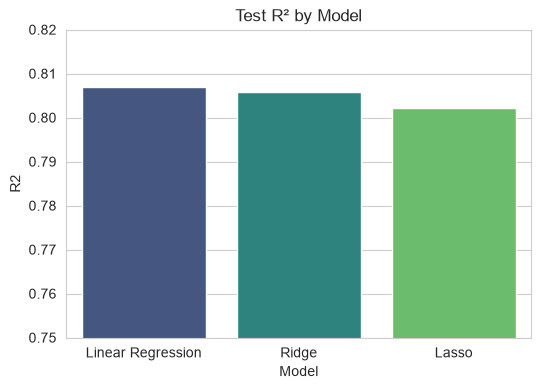

In [27]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Model", y="R2", data=results_df, palette="viridis")
plt.title("Test R² by Model")
plt.ylim(0.75, 0.82)
plt.savefig("../images/model_comparison_r2.png", dpi=100)
plt.show() 

In [25]:
feature_names = lr_pipe.named_steps["preprocessor"].get_feature_names_out()
coefs = lr_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs}).sort_values("coefficient", key=abs, ascending=False)
coef_df

,feature,coefficient
4,category__smoker_yes,23077.764593
0,Num__age,3472.975553
1,Num__bmi,1927.828251
6,category__region_southeast,-838.919616
7,category__region_southwest,-659.139752
2,Num__children,636.501185
5,category__region_northwest,-391.761455
3,category__sex_male,-101.542054


C:\Users\shreyas\AppData\Local\Temp\ipykernel_11328\1123405712.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="coefficient", y="feature", data=coef_df, palette="coolwarm")


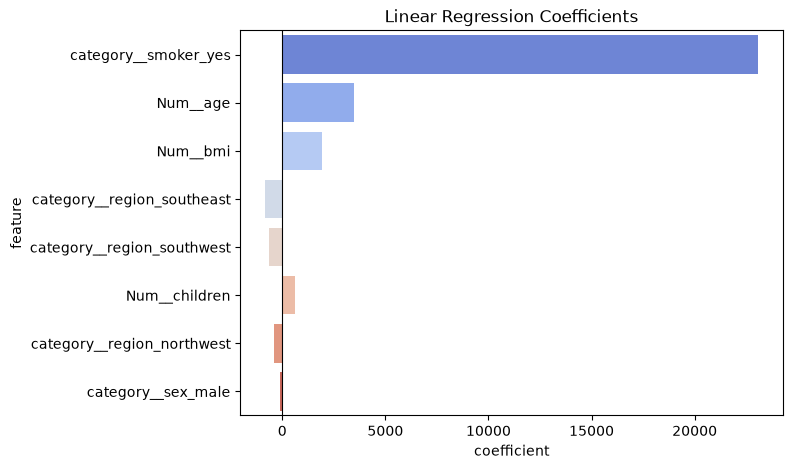

In [ ]:
plt.figure(figsize=(7, 5))
sns.barplot(x="coefficient", y="feature", data=coef_df, palette="coolwarm")
plt.title("Linear Regression Coefficients")
plt.axvline(0, color="black", linewidth=0.8)
plt.savefig("../images/coefficients.png", dpi=100)
plt.show()

**Module 3 Summary**
- Plain **Linear Regression performs best** (RMSE/R²) — Ridge and Lasso don't meaningfully improve on it
- **`smoker_yes` dominates the coefficients** (~+$22,900), confirming the Module 1 EDA finding with an exact number — roughly 6x the next-largest effect (`age`)

## Module 4 — Evaluation & Diagnostics

In [ ]:
pred_train = lr_pipe.predict(X_train)
r2_train = r2_score(y_train,pred_train)

n_train ,k = X_train.shape[0] , X_train_transform.shape[1]
adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - k - 1)

n_test = X_test.shape[0]
adj_r2_test = 1 - (1 - r2_lr) * (n_test - 1) / (n_test - k - 1)

print(f"Train  -> R2: {r2_train:.4f}, Adjusted R2: {adj_r2_train:.4f}")
print(f"Test   -> R2: {r2_lr:.4f}, Adjusted R2: {adj_r2_test:.4f}")

Train  -> R2: 0.7299, Adjusted R2: 0.7279
Test   -> R2: 0.8069, Adjusted R2: 0.8010


In [ ]:
residuals = y_test.values - pred_lr

print("Residual mean :",round(residuals.mean(),2))
print("Residual std :",round(residuals.std(),2))
print("Residual  :",round(pd.Series(residuals).skew(),3))
print("corr(resid, fitted):", round(np.corrcoef(np.abs(residuals), pred_lr)[0, 1], 3))# for checking homoscedasticity 

Residual mean : 425.26
Residual std : 5941.14
Residual  : 1.243
corr(resid, fitted): 0.636


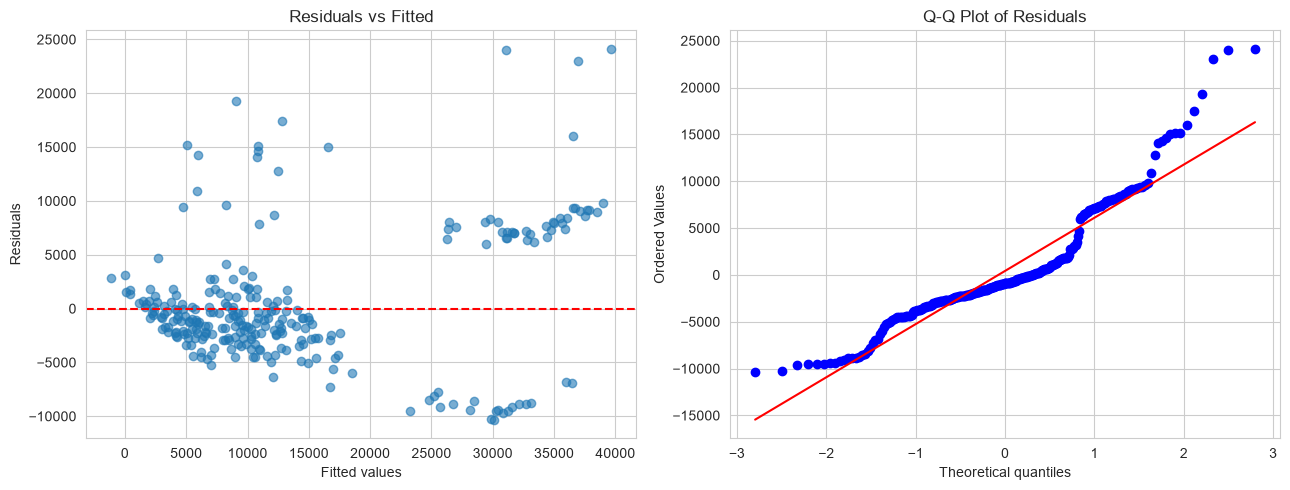

In [64]:
fig , axes = plt.subplots(1,2,figsize=(13,5))


axes[0].scatter(pred_lr, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.savefig("../images/residual_diagnostics.png", dpi=100)
plt.show()


In [ ]:
# vif checking 
X_train_df = pd.DataFrame(x_train_transform,columns=feature_names)

vif_data = pd.DataFrame({
                        "Features " : feature_names,
                        "VIF": [variance_inflation_factor(X_train_df.values,i) for i in range(x_train_df.shape[1])]
}).sort_values('VIF',ascending=False)
vif_data 

,Features,VIF
3,category__sex_male,1.696577
6,category__region_southeast,1.352449
5,category__region_northwest,1.239033
4,category__smoker_yes,1.231610
7,category__region_southwest,1.211119
1,Num__bmi,1.090140
0,Num__age,1.022100
2,Num__children,1.004936


**Module 4 Summary — Assumption Scorecard**

| Assumption | Status | Evidence |
|---|---|---|
| Linearity | Partially violated | Missing `smoker × bmi` interaction |
| Homoscedasticity | Violated | corr(\|residual\|, fitted) ≈ 0.64 |
| Normality of residuals | Violated | Residual skew ≈ 1.24 |
| No multicollinearity | Holds | All VIF < 2 |

**Root cause:** high-BMI smokers cost disproportionately more than the additive model predicts — this single missing interaction explains both the heteroscedasticity and the residual skew. The VIF result also explains Module 3's finding: with no multicollinearity present, Ridge/Lasso had nothing meaningful to correct.

**Next step (future work):** add an explicit `smoker × bmi` interaction term, or move to a model that captures interactions natively (Random Forest / Gradient Boosting).